In [ ]:
!pip install pytorch-lightning --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 58.5 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhilroxtomar/brain-tumor-segmentation")

print("Path to dataset files:", path)

100%|██████████| 312M/312M [00:01<00:00, 206MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nikhilroxtomar/brain-tumor-segmentation/versions/1


In [ ]:
import shutil
import os

# Source path (your current dataset location)
source_path = "/root/.cache/kagglehub/datasets/nikhilroxtomar/brain-tumor-segmentation/versions/1"

# Destination path in Google Colab
destination_path = "/content/brain-tumor-segmentation-dataset"

# Copy the entire directory
try:
    shutil.copytree(source_path, destination_path)
    print(f"Dataset successfully copied to: {destination_path}")
    print(f"Dataset contents: {os.listdir(destination_path)}")
except FileExistsError:
    print(f"Destination path already exists. Checking contents...")
    if os.path.exists(destination_path):
        print(f"Contents: {os.listdir(destination_path)}")
except Exception as e:
    print(f"An error occurred: {e}")

Dataset successfully copied to: /content/brain-tumor-segmentation-dataset
Dataset contents: ['images', 'masks']


In [ ]:
IMG_SIZE = 256
BATCH_SIZE = 16
NUM_WORKERS = 2
LR = 1e-3
MAX_EPOCHS = 60

image_dir = '/content/brain_tumor/images'
mask_dir = '/content/brain_tumor/masks'

In [ ]:
image_files = sorted([os.path.join(image_dir, x) for x in os.listdir(image_dir)])
mask_files = sorted([os.path.join(mask_dir, x) for x in os.listdir(mask_dir)])

train_val_imgs, test_imgs, train_val_masks, test_masks = train_test_split(
    image_files, mask_files, test_size=0.1, random_state=42)

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    train_val_imgs, train_val_masks, test_size=1/9, random_state=42)

In [ ]:
class BrainDataset(Dataset):
    def __init__(self, image_paths, mask_paths):
        self.image_paths = image_paths
        self.mask_paths = mask_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        img = np.transpose(img, (2, 0, 1))  # HWC → CHW

        mask = cv2.imread(self.mask_paths[idx], 0)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = mask / 255.0
        mask = np.expand_dims(mask, 0)

        return torch.tensor(img, dtype=torch.float32), \
               torch.tensor(mask, dtype=torch.float32)

In [ ]:
train_loader = DataLoader(
    BrainDataset(train_imgs, train_masks),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    BrainDataset(val_imgs, val_masks),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    BrainDataset(test_imgs, test_masks),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

In [ ]:
def dice_coefficient(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    intersection = (preds * targets).sum(dim=(2,3))
    union = preds.sum(dim=(2,3)) + targets.sum(dim=(2,3))

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice.mean()


def iou_score(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    intersection = (preds * targets).sum(dim=(2,3))
    union = preds.sum(dim=(2,3)) + targets.sum(dim=(2,3)) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()

In [ ]:
class UNet(pl.LightningModule):
    def __init__(self, lr=LR):
        super().__init__()
        self.lr = lr

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.c1 = conv_block(3, 16)
        self.p1 = nn.MaxPool2d(2)

        self.c2 = conv_block(16, 32)
        self.p2 = nn.MaxPool2d(2)

        self.c3 = conv_block(32, 64)
        self.p3 = nn.MaxPool2d(2)

        self.b = conv_block(64, 256)

        self.u3 = nn.ConvTranspose2d(256, 64, 2, stride=2)
        self.c6 = conv_block(128, 64)

        self.u2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.c7 = conv_block(64, 32)

        self.u1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.c8 = conv_block(32, 16)

        self.out = nn.Conv2d(16, 1, 1)

        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, x):
        c1 = self.c1(x); p1 = self.p1(c1)
        c2 = self.c2(p1); p2 = self.p2(c2)
        c3 = self.c3(p2); p3 = self.p3(c3)

        b = self.b(p3)

        u3 = self.u3(b)
        c6 = self.c6(torch.cat([u3, c3], dim=1))

        u2 = self.u2(c6)
        c7 = self.c7(torch.cat([u2, c2], dim=1))

        u1 = self.u1(c7)
        c8 = self.c8(torch.cat([u1, c1], dim=1))

        return self.out(c8)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        bce_loss = self.bce(logits, y)
        dice = dice_coefficient(logits, y)
        loss = bce_loss + (1 - dice)

        self.log("train_loss", loss)
        self.log("train_dice", dice)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        bce_loss = self.bce(logits, y)
        dice = dice_coefficient(logits, y)
        iou = iou_score(logits, y)
        loss = bce_loss + (1 - dice)

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_dice", dice, prog_bar=True)
        self.log("val_iou", iou, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        dice = dice_coefficient(logits, y)
        iou = iou_score(logits, y)

        self.log("test_dice", dice)
        self.log("test_iou", iou)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

In [ ]:
model = UNet()

early_stop = EarlyStopping(monitor="val_loss", patience=20)
checkpoint = ModelCheckpoint(monitor="val_loss", save_top_k=1)

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="gpu",
    devices=1,
    callbacks=[early_stop, checkpoint]
)

trainer.fit(model, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ c1   │ Sequential        │    448 │ train │     0 │
│ 1  │ p1   │ MaxPool2d         │      0 │ train │     0 │
│ 2  │ c2   │ Sequential        │  4.6 K │ train │     0 │
│ 3  │ p2   │ MaxPool2d         │      0 │ train │     0 │
│ 4  │ c3   │ Sequential        │ 18.5 K │ train │     0 │
│ 5  │ p3   │ MaxPool2d         │      0 │ train │     0 │
│ 6  │ b    │ Sequential        │  147 K │ train │     0 │
│ 7  │ u3   │ ConvTranspose2d   │ 65.6 K │ train │     0 │
│ 8  │ c6   │ Sequential        │ 73.8 K │ train │     0 │
│ 9  │ u2   │ ConvTranspose2d   │  8.2 K │ train │     0 │
│ 10 │ c7   │ Sequential        │ 18.5 K │ train │     0 │
│ 11 │ u1   │ ConvTranspose2d   │  2.1 K │ train │     0 │
│ 12 │ c8   │ Sequential        │  4.6 K │ train │     0 │
│ 13 │ out  │ Conv2d            │     17 │ train │     0 │
│ 14 │ bce  │ BCEWithLogitsLoss │      0 │ train │     0 │
└────┴──────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 344 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 344 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 29                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=60` reached.


In [ ]:
trainer.test(model, test_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_dice         │    0.6330982446670532     │
│         test_iou          │    0.5165486931800842     │
└───────────────────────────┴───────────────────────────┘

[{'test_dice': 0.6330982446670532, 'test_iou': 0.5165486931800842}]

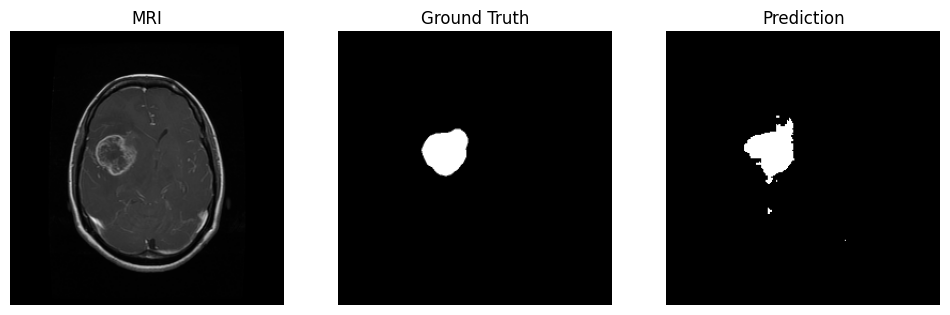

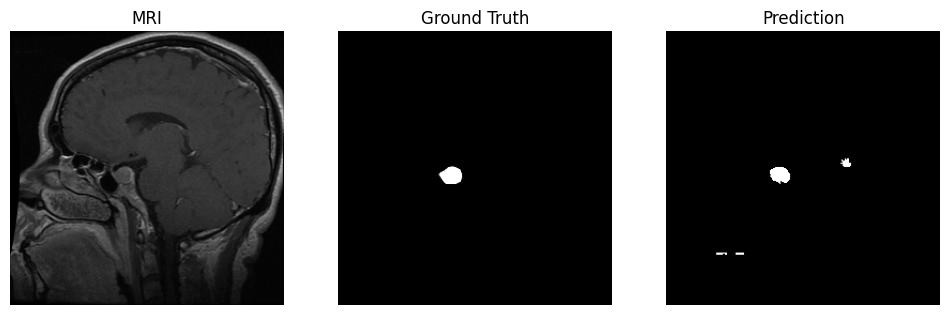

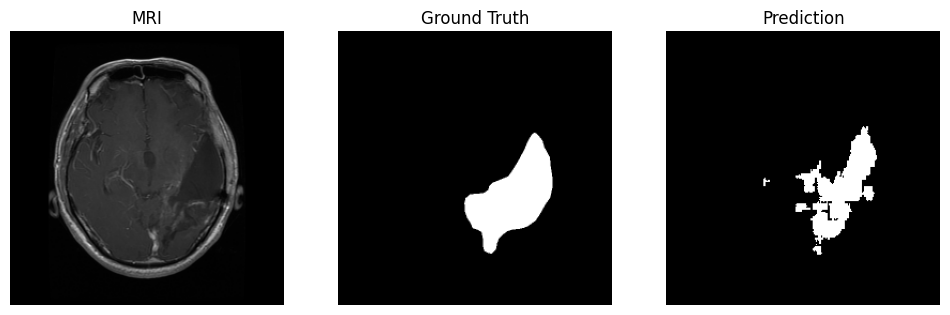

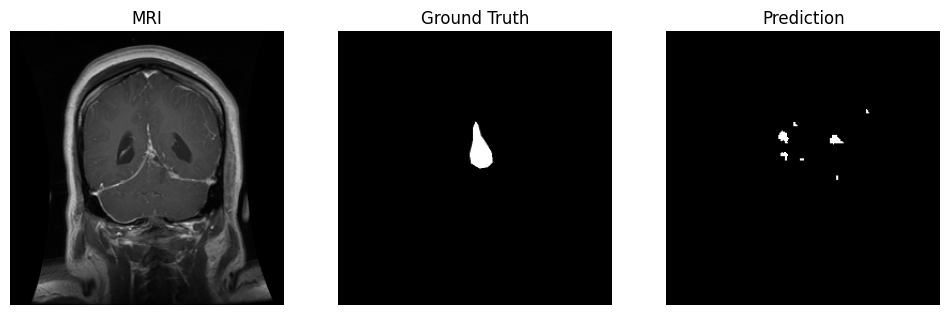

In [ ]:
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        preds = torch.sigmoid(model(images))
        preds = (preds > 0.5).float()

        for i in range(4):
            plt.figure(figsize=(12,4))

            plt.subplot(1,3,1)
            plt.title("MRI")
            plt.imshow(images[i].cpu().permute(1,2,0))
            plt.axis("off")

            plt.subplot(1,3,2)
            plt.title("Ground Truth")
            plt.imshow(masks[i][0], cmap='gray')
            plt.axis("off")

            plt.subplot(1,3,3)
            plt.title("Prediction")
            plt.imshow(preds[i][0].cpu(), cmap='gray')
            plt.axis("off")

            plt.show()
        break

# 2nd try

Testing ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20/20 0:00:02 • 0:00:00 8.07it/s

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_dice         │    0.8290281891822815     │
│         test_iou          │    0.7499326467514038     │
└───────────────────────────┴───────────────────────────┘


Visualizing predictions...


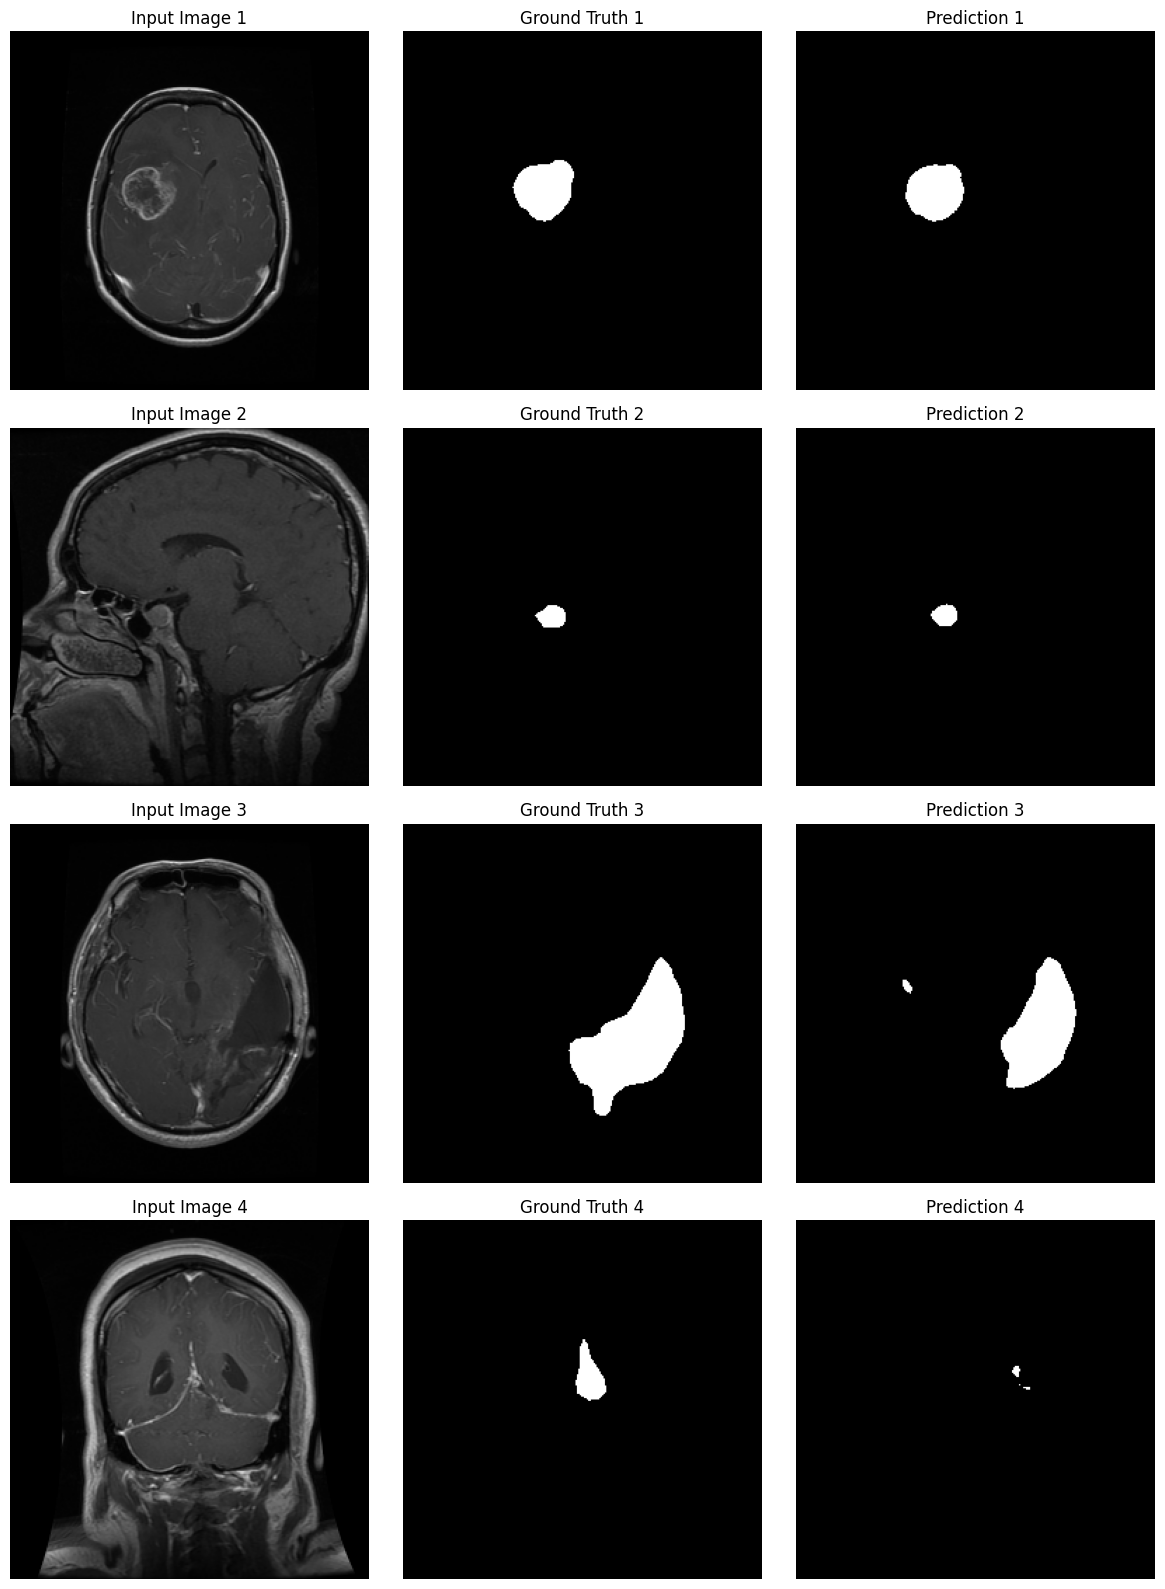

Predictions visualization saved as 'predictions.png'
Final model saved as 'brain_tumor_unet_final.pth'

✅ Training complete!


In [ ]:
# Import all necessary libraries
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================
IMG_SIZE = 256
BATCH_SIZE = 16
NUM_WORKERS = 2  # Reduced from 4 to avoid the warning
MAX_EPOCHS = 100
LR = 1e-4

# Set paths
image_dir = "/content/brain_tumor/images"
mask_dir = "/content/brain_tumor/masks"

# ==================== DATA PREPARATION ====================
print("Loading dataset...")
image_files = sorted([os.path.join(image_dir, x) for x in os.listdir(image_dir) if x.endswith(('.png', '.jpg', '.jpeg'))])
mask_files = sorted([os.path.join(mask_dir, x) for x in os.listdir(mask_dir) if x.endswith(('.png', '.jpg', '.jpeg'))])

print(f"Found {len(image_files)} images and {len(mask_files)} masks")

# Split dataset
train_val_imgs, test_imgs, train_val_masks, test_masks = train_test_split(
    image_files, mask_files, test_size=0.1, random_state=42)

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    train_val_imgs, train_val_masks, test_size=1/9, random_state=42)

print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")

# ==================== DATASET CLASS ====================
class BrainDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None, augment=False):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Load mask
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        # Normalize
        img = img.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0
        mask = (mask > 0.5).astype(np.float32)

        # Simple augmentation for training
        if self.augment:
            # Random horizontal flip
            if np.random.random() > 0.5:
                img = np.fliplr(img).copy()
                mask = np.fliplr(mask).copy()

            # Random rotation (90, 180, 270 degrees)
            if np.random.random() > 0.5:
                k = np.random.randint(1, 4)
                img = np.rot90(img, k, axes=(0, 1)).copy()
                mask = np.rot90(mask, k, axes=(0, 1)).copy()

            # Random brightness adjustment
            if np.random.random() > 0.5:
                brightness_factor = np.random.uniform(0.8, 1.2)
                img = np.clip(img * brightness_factor, 0, 1)

        # Convert to tensor
        img = torch.from_numpy(img.transpose(2, 0, 1)).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()

        return img, mask

# ==================== METRICS ====================
def dice_coefficient(preds, targets, smooth=1e-6):
    """Calculate Dice coefficient"""
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice.mean()

def iou_score(preds, targets, smooth=1e-6):
    """Calculate IoU score"""
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()

# ==================== U-NET IMPLEMENTATION ====================
class DoubleConv(nn.Module):
    """(Conv2d -> BN -> ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=False):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        # Handle size mismatches
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(pl.LightningModule):
    def __init__(self, n_channels=3, n_classes=1, features=[64, 128, 256, 512], lr=LR):
        super(UNet, self).__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = False
        self.features = features

        # Encoder
        self.inc = DoubleConv(n_channels, features[0])
        self.down1 = Down(features[0], features[1])
        self.down2 = Down(features[1], features[2])
        self.down3 = Down(features[2], features[3])

        # Bottleneck
        factor = 2 if self.bilinear else 1
        self.down4 = Down(features[3], features[3] * 2 // factor)

        # Decoder
        self.up1 = Up(features[3] * 2, features[3] // factor, self.bilinear)
        self.up2 = Up(features[3], features[2] // factor, self.bilinear)
        self.up3 = Up(features[2], features[1] // factor, self.bilinear)
        self.up4 = Up(features[1], features[0], self.bilinear)

        # Output
        self.outc = OutConv(features[0], n_classes)

        # Loss
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # Decoder with skip connections
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        # Output
        logits = self.outc(x)
        return logits

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)

        bce_loss = self.bce(logits, y)
        dice = dice_coefficient(logits, y)
        loss = bce_loss + (1 - dice)

        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_dice", dice, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_bce", bce_loss, on_step=False, on_epoch=True)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)

        bce_loss = self.bce(logits, y)
        dice = dice_coefficient(logits, y)
        iou = iou_score(logits, y)
        loss = bce_loss + (1 - dice)

        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_dice", dice, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_iou", iou, on_step=False, on_epoch=True, prog_bar=True)

        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)

        dice = dice_coefficient(logits, y)
        iou = iou_score(logits, y)

        self.log("test_dice", dice, on_step=False, on_epoch=True)
        self.log("test_iou", iou, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)

        # FIXED: Removed verbose parameter
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=5
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
            }
        }

# ==================== CREATE DATALOADERS ====================
print("Creating dataloaders...")
train_dataset = BrainDataset(train_imgs, train_masks, augment=True)
val_dataset = BrainDataset(val_imgs, val_masks, augment=False)
test_dataset = BrainDataset(test_imgs, test_masks, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ==================== INITIALIZE MODEL ====================
print("\nInitializing U-Net model...")
model = UNet(n_channels=3, n_classes=1, lr=LR)
print(f"\nModel has {sum(p.numel() for p in model.parameters()):,} parameters")

# ==================== SETUP CALLBACKS ====================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    mode="min",
    verbose=True
)

checkpoint = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=3,
    filename="unet-brain-tumor-{epoch:02d}-{val_loss:.4f}",
    verbose=True
)

# ==================== TRAINER ====================
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="gpu",
    devices=1,
    callbacks=[early_stop, checkpoint],
    log_every_n_steps=5,
    precision="16-mixed",  # FIXED: Changed from 16 to "16-mixed"
)

# ==================== TRAIN ====================
print("\nStarting training...")
trainer.fit(model, train_loader, val_loader)

# ==================== TEST ====================
print("\nTesting best model...")
trainer.test(model, test_loader, ckpt_path="best")

# ==================== VISUALIZE PREDICTIONS ====================
def visualize_predictions(model, test_loader, num_samples=4):
    """Visualize model predictions on test samples"""
    model.eval()
    device = next(model.parameters()).device

    # Get samples
    batch = next(iter(test_loader))
    images, masks = batch
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        logits = model(images)
        preds = torch.sigmoid(logits)
        preds = (preds > 0.5).float()

    # Move to CPU for visualization
    images = images.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    for i in range(num_samples):
        # Original image
        axes[i, 0].imshow(images[i].permute(1, 2, 0).numpy())
        axes[i, 0].set_title(f'Input Image {i+1}')
        axes[i, 0].axis('off')

        # Ground truth mask
        axes[i, 1].imshow(masks[i, 0].numpy(), cmap='gray')
        axes[i, 1].set_title(f'Ground Truth {i+1}')
        axes[i, 1].axis('off')

        # Predicted mask
        axes[i, 2].imshow(preds[i, 0].numpy(), cmap='gray')
        axes[i, 2].set_title(f'Prediction {i+1}')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150)
    plt.show()
    print("Predictions visualization saved as 'predictions.png'")

# Visualize predictions
print("\nVisualizing predictions...")
visualize_predictions(model, test_loader)

# ==================== SAVE FINAL MODEL ====================
torch.save(model.state_dict(), "brain_tumor_unet_final.pth")
print("Final model saved as 'brain_tumor_unet_final.pth'")

print("\n✅ Training complete!")

In [ ]:
import files

files.download("brain_tumor_unet_final.pth")

In [ ]:
from google.colab import files
files.download("brain_tumor_unet_final.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>